In [1]:
import kagglehub
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from PIL import Image
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, precision_score, log_loss,
                             recall_score, balanced_accuracy_score, f1_score, roc_curve, auc)

import tensorflow as tf

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from torchsummary import summary

RANDOM_STATE = 42
IMAGE_SIZE = (32, 32)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

OUT_DIR = Path("../outputs")
MODEL_DIR = OUT_DIR / "models"
FIGURE_DIR = OUT_DIR / "figures"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

## Controlled configuration for CNN/EfficientNet ablation experiments

In [2]:
ABLATION_EXPERIMENTS = {
    "A": {
        "name": "baseline",
        "use_enhancement": False,
        "use_augmentation": False,
    },
    "B": {
        "name": "enhancement_only",
        "use_enhancement": True,
        "use_augmentation": False,
    },
    "C": {
        "name": "augmentation_only",
        "use_enhancement": False,
        "use_augmentation": True,
    },
    "D": {
        "name": "enhancement_plus_augmentation",
        "use_enhancement": True,
        "use_augmentation": True,
    },
}
ACTIVE_EXPERIMENT = "A"

EXPERIMENT_CONFIG = ABLATION_EXPERIMENTS[ACTIVE_EXPERIMENT]
EXPERIMENT_NAME = EXPERIMENT_CONFIG["name"]
USE_ENHANCEMENT = EXPERIMENT_CONFIG["use_enhancement"]
USE_AUGMENTATION = EXPERIMENT_CONFIG["use_augmentation"]
MODEL_PATH_COLUMN = "enhanced_path" if USE_ENHANCEMENT else "image_path"

# Keep ablation artifacts separate so one run cannot overwrite another.
ABLATION_MODEL_DIR = MODEL_DIR / EXPERIMENT_NAME
ABLATION_FIGURE_DIR = FIGURE_DIR / EXPERIMENT_NAME
ABLATION_MODEL_DIR.mkdir(parents=True, exist_ok=True)
ABLATION_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

## Kaggle dataset setup

Download `kmader/skin-cancer-mnist-ham10000` with `kagglehub`, reads `HAM10000_metadata.csv`, and maps each `image_id` to the corresponding JPG in the two image folders.

In [3]:
# Download the dataset from Kaggle

DATASET = "kmader/skin-cancer-mnist-ham10000"
data_dir = Path(kagglehub.dataset_download(DATASET))

print("Dataset directory:", data_dir)
print("Top-level files/folders:")
for path in sorted(data_dir.iterdir()):
    print(" -", path.name)
    
images_part_1_dir = data_dir / "HAM10000_images_part_1"
images_part_2_dir = data_dir / "HAM10000_images_part_2"

print("Number of images in 'HAM10000_images_part_1':", len(list(images_part_1_dir.glob("*.jpg"))))
print("Number of images in 'HAM10000_images_part_2':", len(list(images_part_2_dir.glob("*.jpg"))))

Dataset directory: C:\Users\thanh\.cache\kagglehub\datasets\kmader\skin-cancer-mnist-ham10000\versions\2
Top-level files/folders:
 - HAM10000_images_part_1
 - HAM10000_images_part_2
 - HAM10000_metadata.csv
 - hmnist_28_28_L.csv
 - hmnist_28_28_RGB.csv
 - hmnist_8_8_L.csv
 - hmnist_8_8_RGB.csv
Number of images in 'HAM10000_images_part_1': 5000
Number of images in 'HAM10000_images_part_2': 5015


In [4]:
# Load metadata and map every image_id to its JPG file

metadata = list(data_dir.rglob("HAM10000_metadata.csv"))
if not metadata:
    raise FileNotFoundError("HAM10000_metadata.csv was not found.")

metadata_path = metadata[0]
df = pd.read_csv(metadata_path)

# Images are stored across HAM10000_images_part_1 and part_2
image_files = list(data_dir.rglob("*.jpg"))
image_path_by_id = {path.stem: str(path) for path in image_files}
df["image_path"] = df["image_id"].map(image_path_by_id)

missing_images = df["image_path"].isna().sum()
if missing_images:
    missing_ids = df.loc[df["image_path"].isna(), "image_id"].head(10).tolist()
    raise FileNotFoundError(
        f"Could not locate {missing_images} image files. Example missing IDs: {missing_ids}"
    )

print(df.head())
print("Metadata shape:", df.shape)
print("Images discovered:", len(image_path_by_id))


     lesion_id      image_id   dx dx_type   age   sex localization  \
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp   
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp   
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp   
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp   
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear   

                                          image_path  
0  C:\Users\thanh\.cache\kagglehub\datasets\kmade...  
1  C:\Users\thanh\.cache\kagglehub\datasets\kmade...  
2  C:\Users\thanh\.cache\kagglehub\datasets\kmade...  
3  C:\Users\thanh\.cache\kagglehub\datasets\kmade...  
4  C:\Users\thanh\.cache\kagglehub\datasets\kmade...  
Metadata shape: (10015, 8)
Images discovered: 10015


## Prepare labels to split Train/Test sets

In [5]:
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["dx"])
class_names = label_encoder.classes_

print("Classes:", list(enumerate(class_names)))
print("Full dataset shape:", df.shape)
print("Unique lesions:", df["lesion_id"].nunique())

Classes: [(0, 'akiec'), (1, 'bcc'), (2, 'bkl'), (3, 'df'), (4, 'mel'), (5, 'nv'), (6, 'vasc')]
Full dataset shape: (10015, 9)
Unique lesions: 7470


In [6]:
sgkf = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)\
    
df["fold"] = -1
for fold, (_, fold_indices) in enumerate(sgkf.split(df, y=df["label"], groups=df["lesion_id"])):
    df.loc[fold_indices, "fold"] = fold

TEST_FOLD = 0           # Choose first fold as test set
VALIDATION_FOLD = 1     # Choose second fold as validation set

train_df = df.loc[~ df["fold"].isin([TEST_FOLD, VALIDATION_FOLD])].copy()   # Copy Folds 2-9 for training
val_df = df.loc[df["fold"] == VALIDATION_FOLD].copy()
test_df = df.loc[df["fold"] == TEST_FOLD].copy()

for split_name, split_df in {
    "train": train_df,
    "validation": val_df,
    "test": test_df,
}.items():
    print(
        f"{split_name:10s}: {len(split_df):5d} images, "
        f"{split_df['lesion_id'].nunique():5d} lesions"
    )
    print(split_df["dx"].value_counts(normalize=True).sort_index().round(3))
    print()

# Leakage checks.
train_lesions = set(train_df["lesion_id"])
val_lesions = set(val_df["lesion_id"])
test_lesions = set(test_df["lesion_id"])

assert train_lesions.isdisjoint(val_lesions)
assert train_lesions.isdisjoint(test_lesions)
assert val_lesions.isdisjoint(test_lesions)
assert len(train_df) + len(val_df) + len(test_df) == len(df)

print("No Leakage (no lesion_id appears in multiple splits).")

train     :  8011 images,  5975 lesions
dx
akiec    0.033
bcc      0.051
bkl      0.110
df       0.011
mel      0.111
nv       0.669
vasc     0.014
Name: proportion, dtype: float64

validation:  1002 images,   748 lesions
dx
akiec    0.033
bcc      0.052
bkl      0.110
df       0.011
mel      0.111
nv       0.670
vasc     0.014
Name: proportion, dtype: float64

test      :  1002 images,   747 lesions
dx
akiec    0.032
bcc      0.051
bkl      0.110
df       0.012
mel      0.112
nv       0.670
vasc     0.014
Name: proportion, dtype: float64

No Leakage (no lesion_id appears in multiple splits).


## EDA & Preprocessing

In [7]:
# IMAGE PREPROCESSING black hair removal, CLAHE, resizing, normalization, and augmentation

COMMON_IMAGE_SIZE = (224, 224)
COMMON_ENHANCED_DIR = OUT_DIR / "enhanced_images_224x224"
COMMON_ENHANCED_DIR.mkdir(parents=True, exist_ok=True)

def remove_hair_blackhat(image_bgr, kernel_size=17, threshold=10):
    """Remove dark hair-like structures with black-hat filtering + inpainting."""
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (kernel_size, kernel_size),
    )
    blackhat = cv2.morphologyEx(
        gray,
        cv2.MORPH_BLACKHAT,
        kernel,
    )
    _, hair_mask = cv2.threshold(
        blackhat,
        threshold,
        255,
        cv2.THRESH_BINARY,
    )
    return cv2.inpaint(
        image_bgr,
        hair_mask,
        1,
        cv2.INPAINT_TELEA,
    )

def apply_clahe(image_bgr, clip_limit=2.0, tile_size=(8, 8)):
    """Apply CLAHE to the LAB luminance channel while preserving color."""
    lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB)
    clahe = cv2.createCLAHE(
        clipLimit=clip_limit,
        tileGridSize=tile_size,
    )
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

def build_enhanced_cache(dataframe, cache_dir, image_size=COMMON_IMAGE_SIZE):
    """Build the shared black-hat -> CLAHE -> resize PNG cache once."""
    unique_images = (
        dataframe[["image_id", "image_path"]]
        .drop_duplicates("image_id")
        .reset_index(drop=True)
    )

    created = 0
    skipped = 0

    for i, row in unique_images.iterrows():
        output_path = cache_dir / f"{row['image_id']}.png"

        if output_path.exists():
            skipped += 1
            continue

        image_bgr = cv2.imread(str(row["image_path"]), cv2.IMREAD_COLOR)
        if image_bgr is None:
            raise FileNotFoundError(f"Could not load image: {row['image_path']}")

        image_bgr = remove_hair_blackhat(image_bgr)
        image_bgr = apply_clahe(image_bgr)
        image_bgr = cv2.resize(
            image_bgr,
            tuple(map(int, image_size)),
            interpolation=cv2.INTER_AREA,
        )
        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        Image.fromarray(image_rgb).save(output_path, format="PNG", optimize=False)

        created += 1
        if created % 1000 == 0:
            print(
                f"Enhanced/cached {created} new images "
                f"({i + 1}/{len(unique_images)} checked)"
            )

    print(
        f"Enhanced cache complete. "
        f"Created: {created}, already existed: {skipped}"
    )

def attach_enhanced_paths(split_df):
    split_df = split_df.copy()
    split_df["enhanced_path"] = split_df["image_id"].map(
        lambda image_id: str(COMMON_ENHANCED_DIR / f"{image_id}.png")
    )
    missing = [p for p in split_df["enhanced_path"] if not Path(p).exists()]
    if missing:
        raise FileNotFoundError(
            f"Missing {len(missing)} enhanced images. Example: {missing[:3]}"
        )
    return split_df

if USE_ENHANCEMENT:
    # Build one common cache across the already leakage-safe splits.
    common_cache_df = pd.concat(
        [train_df, val_df, test_df],
        ignore_index=True,
    )
    build_enhanced_cache(
        common_cache_df,
        COMMON_ENHANCED_DIR,
        COMMON_IMAGE_SIZE,
    )
    
    train_df = attach_enhanced_paths(train_df)
    val_df = attach_enhanced_paths(val_df)
    test_df = attach_enhanced_paths(test_df)

    # Sanity check: original vs common deterministic enhancement.
    preview_row = train_df.iloc[0]
    with Image.open(preview_row["image_path"]) as image:
        preview_original = image.convert("RGB")
    with Image.open(preview_row["enhanced_path"]) as image:
        preview_enhanced = image.convert("RGB")

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(preview_original)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(preview_enhanced)
    plt.title("Black-hat + CLAHE + Resize")
    plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Enhancement disabled for this ablation.")

Enhancement disabled for this ablation.


In [8]:
# Build the 32x32 arrays used by Logistic Regression, Random Forest, and LSTM
def load_image_array(image_path, size=IMAGE_SIZE):
    """Load one local JPG as a normalized RGB NumPy array."""
    with Image.open(image_path) as image:
        image = image.convert("RGB").resize(size)
        return np.asarray(image, dtype=np.float32) / 255.0


def dataframe_to_arrays(split_df, path_column="image_path"):
    """Convert one metadata split into image and integer-label arrays."""
    X = np.stack([load_image_array(path) for path in split_df[path_column]])
    y = split_df["label"].to_numpy(dtype=np.int64)
    return X, y

X_train, y_train = dataframe_to_arrays(train_df, path_column="image_path")
X_val, y_val = dataframe_to_arrays(val_df, path_column="image_path")
X_test, y_test = dataframe_to_arrays(test_df, path_column="image_path")

print("Training set:  ", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:      ", X_test.shape, y_test.shape)
print("Pixel range:", float(X_train.min()), "to", float(X_train.max()))

Training set:   (8011, 32, 32, 3) (8011,)
Validation set: (1002, 32, 32, 3) (1002,)
Test set:       (1002, 32, 32, 3) (1002,)
Pixel range: 0.0 to 1.0


In [9]:
print(train_df.head())
train_df.shape

     lesion_id      image_id   dx dx_type   age   sex localization  \
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp   
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp   
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear   
5  HAM_0001466  ISIC_0027850  bkl   histo  75.0  male          ear   
6  HAM_0002761  ISIC_0029176  bkl   histo  60.0  male         face   

                                          image_path  label  fold  
0  C:\Users\thanh\.cache\kagglehub\datasets\kmade...      2     8  
1  C:\Users\thanh\.cache\kagglehub\datasets\kmade...      2     8  
4  C:\Users\thanh\.cache\kagglehub\datasets\kmade...      2     5  
5  C:\Users\thanh\.cache\kagglehub\datasets\kmade...      2     5  
6  C:\Users\thanh\.cache\kagglehub\datasets\kmade...      2     2  


(8011, 10)

In [10]:
train_df.info()
train_df.describe().T
train_df.columns.tolist()

<class 'pandas.core.frame.DataFrame'>
Index: 8011 entries, 0 to 10014
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     8011 non-null   object 
 1   image_id      8011 non-null   object 
 2   dx            8011 non-null   object 
 3   dx_type       8011 non-null   object 
 4   age           7961 non-null   float64
 5   sex           8011 non-null   object 
 6   localization  8011 non-null   object 
 7   image_path    8011 non-null   object 
 8   label         8011 non-null   int64  
 9   fold          8011 non-null   int64  
dtypes: float64(1), int64(2), object(7)
memory usage: 688.4+ KB


['lesion_id',
 'image_id',
 'dx',
 'dx_type',
 'age',
 'sex',
 'localization',
 'image_path',
 'label',
 'fold']

In [11]:
print("\nMissing values per column:")
display(train_df.isnull().sum())

print('\nDuplicate values per column:')
display(train_df.drop(columns=['image_path']).duplicated().sum())


Missing values per column:


lesion_id        0
image_id         0
dx               0
dx_type          0
age             50
sex              0
localization     0
image_path       0
label            0
fold             0
dtype: int64


Duplicate values per column:


np.int64(0)

In [12]:
print('\nFill missing values in \'age\' with the most common age:')
train_df['age'] = train_df['age'].fillna(train_df['age'].median())
display(train_df.isnull().sum())


Fill missing values in 'age' with the most common age:


lesion_id       0
image_id        0
dx              0
dx_type         0
age             0
sex             0
localization    0
image_path      0
label           0
fold            0
dtype: int64

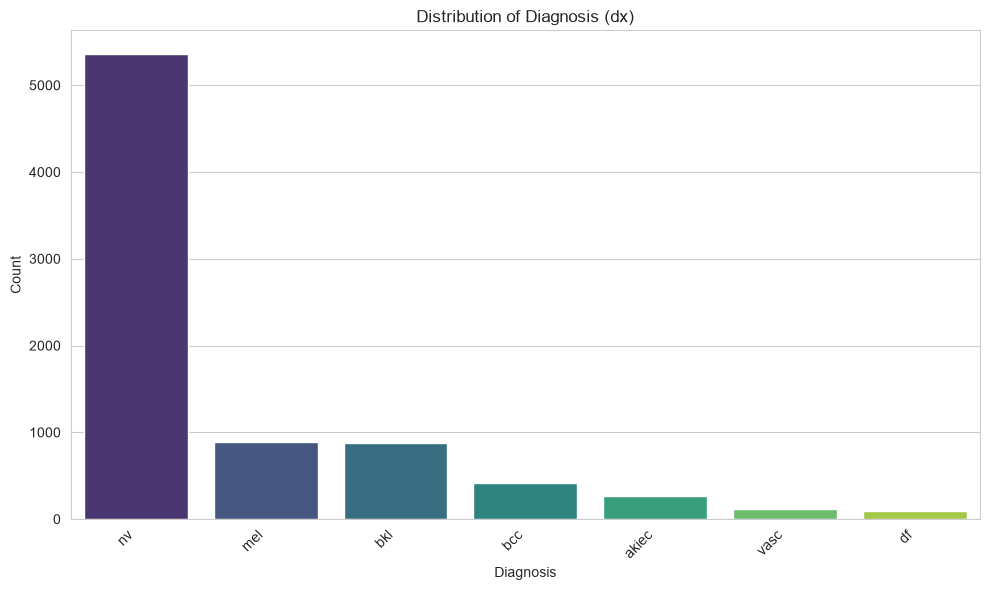

In [13]:
sns.set_style("whitegrid")

# 1. Distribution of 'dx' (diagnosis)
plt.figure(figsize=(10, 6))
sns.countplot(data=train_df, x='dx', order=train_df['dx'].value_counts().index, palette='viridis')
plt.title('Distribution of Diagnosis (dx)')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

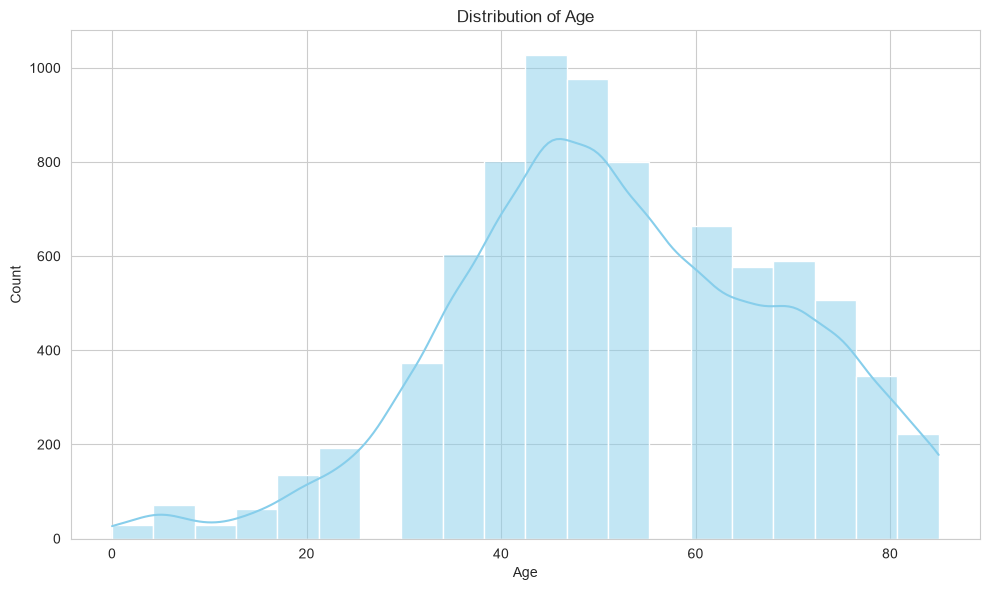

In [14]:
# 2. Distribution of 'age'
plt.figure(figsize=(10, 6))
sns.histplot(data=train_df, x='age', kde=True, bins=20, color='skyblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

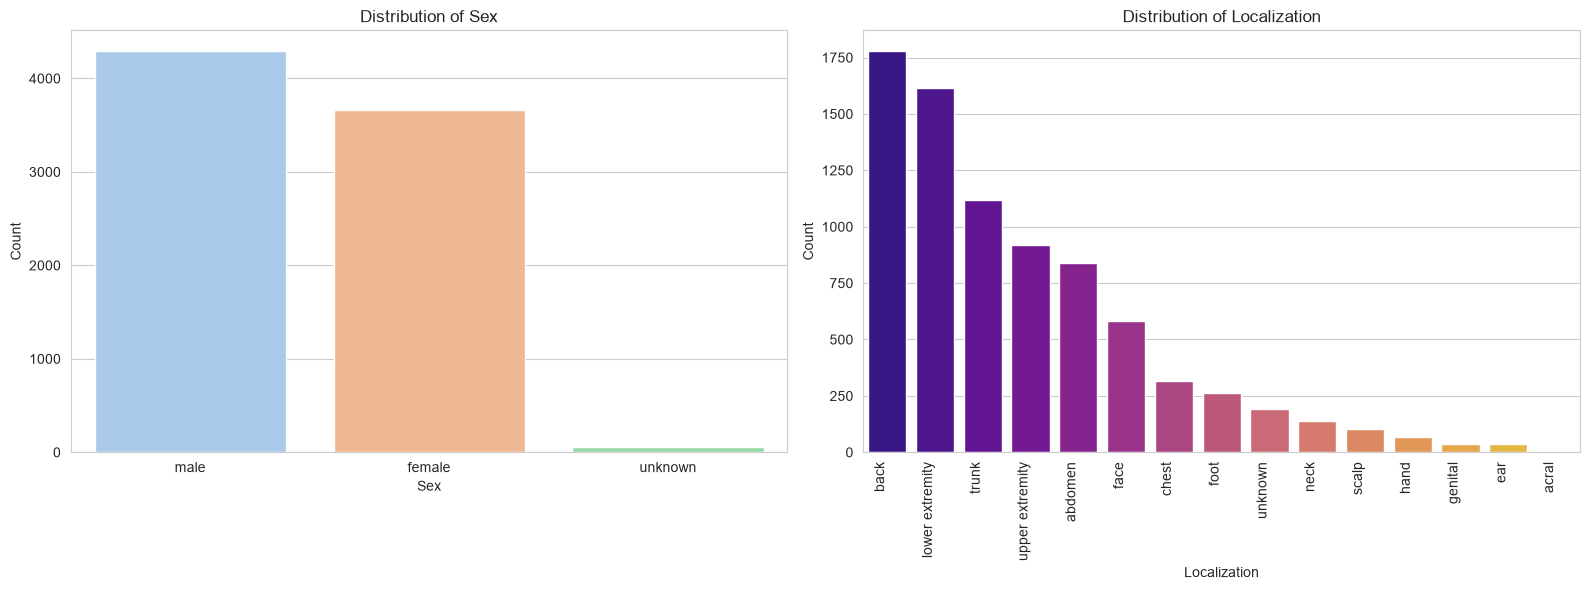

In [15]:
# 3. Distributions of 'sex' and 'localization'
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=train_df, x='sex', ax=axes[0], palette='pastel', order=train_df['sex'].value_counts().index)
axes[0].set_title('Distribution of Sex')
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('Count')

sns.countplot(data=train_df, x='localization', ax=axes[1], palette='plasma', order=train_df['localization'].value_counts().index)
axes[1].set_title('Distribution of Localization')
axes[1].set_xlabel('Localization')
axes[1].set_ylabel('Count')
plt.setp(axes[1].get_xticklabels(), rotation=90, horizontalalignment='right')

plt.tight_layout()
plt.show()

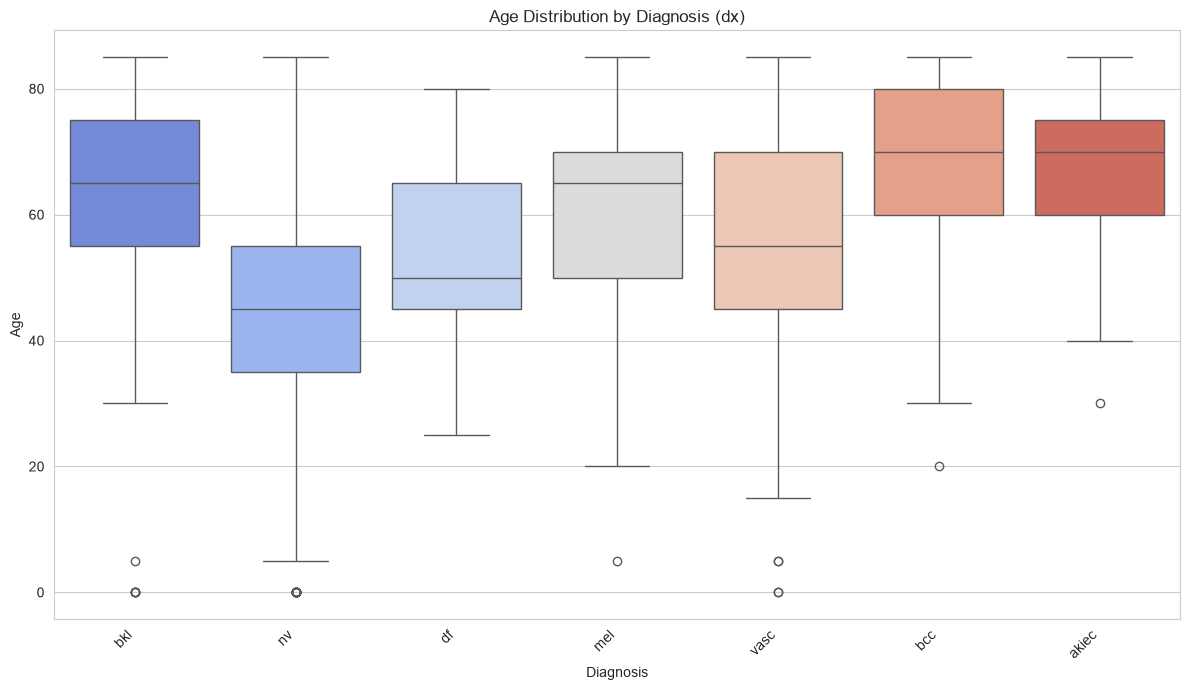

In [16]:
# 4. Age distribution by 'dx'
plt.figure(figsize=(12, 7))
sns.boxplot(data=train_df, x='dx', y='age', palette='coolwarm')
plt.title('Age Distribution by Diagnosis (dx)')
plt.xlabel('Diagnosis')
plt.ylabel('Age')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [17]:
# 5. Detect and handle image outliers
# Brightness and contrast limits are calculated from the **training set only** with the IQR rule. 
# Flagged training images are displayed and then removed before any model is trained. 
# The validation and test sets are not modified, which prevents test-data leakage.

train_brightness = X_train.mean(axis=(1, 2, 3))
train_contrast = X_train.std(axis=(1, 2, 3))

def iqr_outlier_mask(values):
    values = np.asarray(values)
    q1 = np.quantile(values, 0.25)
    q3 = np.quantile(values, 0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (values < lower) | (values > upper)
    return mask, lower, upper


brightness_outlier, brightness_lower, brightness_upper = iqr_outlier_mask(
    train_brightness
)
contrast_outlier, contrast_lower, contrast_upper = iqr_outlier_mask(
    train_contrast
)
train_outlier_mask = brightness_outlier | contrast_outlier

train_metadata_aligned = train_df.reset_index(drop=True)
train_quality_df = pd.DataFrame({
    "training_row": np.arange(len(X_train)),
    "image_id": train_metadata_aligned["image_id"],
    "lesion_id": train_metadata_aligned["lesion_id"],
    "dx": train_metadata_aligned["dx"],
    "brightness": train_brightness,
    "contrast": train_contrast,
    "brightness_outlier": brightness_outlier,
    "contrast_outlier": contrast_outlier,
    "potential_outlier": train_outlier_mask,
})

print("Training images checked:", len(train_quality_df))
print("Brightness limits:", round(brightness_lower, 4), "to", round(brightness_upper, 4))
print("Contrast limits:", round(contrast_lower, 4), "to", round(contrast_upper, 4))
print("Brightness outliers flagged:", int(brightness_outlier.sum()))
print("Contrast outliers flagged:", int(contrast_outlier.sum()))
print("Unique training outliers flagged:", int(train_outlier_mask.sum()))
display(train_quality_df[["brightness", "contrast"]].describe())

Training images checked: 8011
Brightness limits: 0.4245 to 0.8291
Contrast limits: 0.0146 to 0.2991
Brightness outliers flagged: 61
Contrast outliers flagged: 9
Unique training outliers flagged: 70


,brightness,contrast
count,8011.000000,8011.000000
mean,0.626914,0.158109
std,0.075003,0.045614
min,0.249272,0.039369
25%,0.576229,0.121303
50%,0.626972,0.162430
75%,0.677372,0.192421
max,0.901206,0.349866


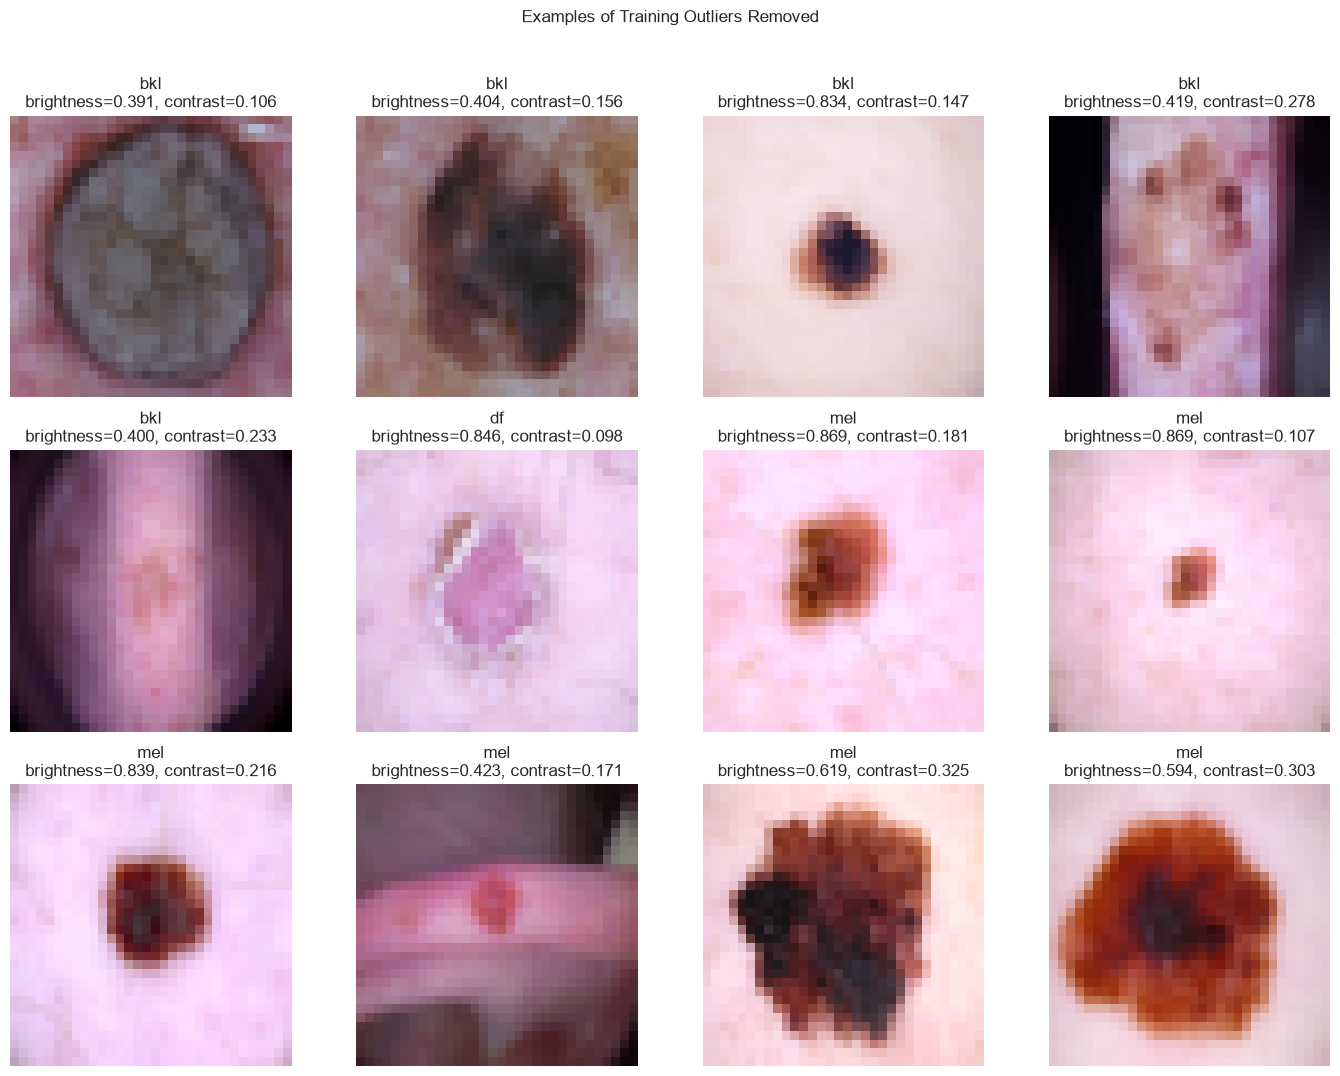

Original training images: 8011
Training outliers removed: 70
Training images remaining: 7941
Validation images unchanged: 1002
Test images unchanged: 1002

Removed images by diagnosis:


,dx,removed_count
0,nv,47
1,mel,17
2,bkl,5
3,df,1


In [18]:
# Display at most 12 examples, but handle every flagged training image.
outlier_indices = np.flatnonzero(train_outlier_mask)
example_indices = outlier_indices[:12]

if len(example_indices) == 0:
    print("No brightness or contrast outliers were flagged.")
else:
    columns = 4
    rows = int(np.ceil(len(example_indices) / columns))
    plt.figure(figsize=(14, 3.5 * rows))

    for plot_number, training_index in enumerate(example_indices, start=1):
        plt.subplot(rows, columns, plot_number)
        plt.imshow(X_train[training_index])
        plt.title(
            f"{class_names[int(y_train[training_index])]}\n"
            f"brightness={train_brightness[training_index]:.3f}, "
            f"contrast={train_contrast[training_index]:.3f}"
        )
        plt.axis("off")

    plt.suptitle("Examples of Training Outliers Removed", y=1.02)
    plt.tight_layout()
    plt.show()

TRAIN_SIZE_BEFORE_OUTLIERS = len(X_train)
OUTLIERS_REMOVED = int(train_outlier_mask.sum())
keep_training_rows = ~train_outlier_mask

removed_outliers_df = train_quality_df.loc[
    train_outlier_mask,
    ["training_row", "image_id", "lesion_id", "dx", "brightness", "contrast"],
].copy()

# Apply the same mask to images, labels, and aligned training metadata.
X_train = X_train[keep_training_rows].copy()
y_train = y_train[keep_training_rows].copy()
train_df = train_metadata_aligned.loc[keep_training_rows].reset_index(drop=True)

assert len(X_train) == len(y_train) == len(train_df)
assert set(np.unique(y_train)) == set(np.arange(len(class_names)))

print("Original training images:", TRAIN_SIZE_BEFORE_OUTLIERS)
print("Training outliers removed:", OUTLIERS_REMOVED)
print("Training images remaining:", len(X_train))
print("Validation images unchanged:", len(X_val))
print("Test images unchanged:", len(X_test))

print("\nRemoved images by diagnosis:")
display(
    removed_outliers_df["dx"]
    .value_counts()
    .rename_axis("dx")
    .reset_index(name="removed_count")
)

In [19]:
removed_ids = set(removed_outliers_df["image_id"])
remaining_ids = set(train_df["image_id"])

overlap = removed_ids & remaining_ids

print("Removed image IDs:", len(removed_ids))
print("Removed IDs still in training data:", len(overlap))

assert len(overlap) == 0

print("All flagged outliers were removed successfully.")

Removed image IDs: 70
Removed IDs still in training data: 0
All flagged outliers were removed successfully.


In [20]:
# 6. Handle Class Imbalance

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = {
    int(class_id): float(weight)
    for class_id, weight in zip(classes, weights)
}
print(class_weights)

{0: 4.329880043620502, 1: 2.7601668404588113, 2: 1.2979731938542007, 3: 12.466248037676609, 4: 1.2994599901816397, 5: 0.21339890357949048, 6: 9.951127819548873}


## Experimental Overview Figure

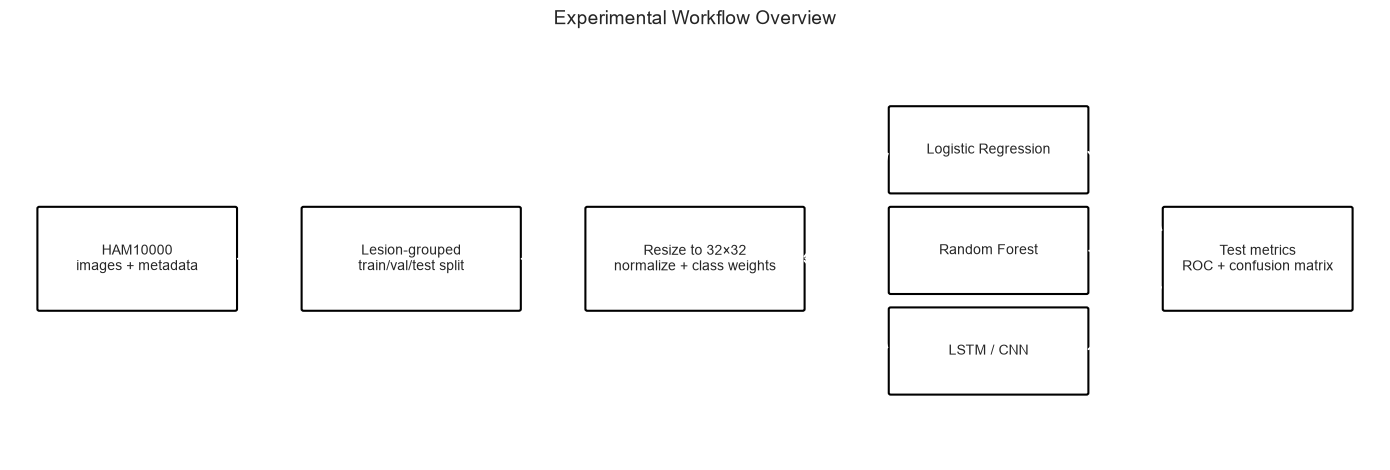

In [21]:
# Overview figure for the paper: data flow, preprocessing, models, and evaluation.
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def add_box(ax, xy, width, height, text):
    box = FancyBboxPatch(
        xy, width, height, boxstyle="round,pad=0.02",
        linewidth=1.5, facecolor="white", edgecolor="black"
    )
    ax.add_patch(box)
    ax.text(xy[0] + width / 2, xy[1] + height / 2, text,
            ha="center", va="center", fontsize=10)

def add_arrow(ax, start, end):
    ax.add_patch(FancyArrowPatch(start, end, arrowstyle="->",
                                 mutation_scale=14, linewidth=1.4))

fig, ax = plt.subplots(figsize=(14, 4.8))
ax.set_xlim(0, 14)
ax.set_ylim(0, 5)
ax.axis("off")

add_box(ax, (0.3, 1.8), 2.0, 1.2, "HAM10000\nimages + metadata")
add_box(ax, (3.0, 1.8), 2.2, 1.2, "Lesion-grouped\ntrain/val/test split")
add_box(ax, (5.9, 1.8), 2.2, 1.2, "Resize to 32×32\nnormalize + class weights")
add_box(ax, (9.0, 3.2), 2.0, 1.0, "Logistic Regression")
add_box(ax, (9.0, 2.0), 2.0, 1.0, "Random Forest")
add_box(ax, (9.0, 0.8), 2.0, 1.0, "LSTM / CNN")
add_box(ax, (11.8, 1.8), 1.9, 1.2, "Test metrics\nROC + confusion matrix")

add_arrow(ax, (2.3, 2.4), (3.0, 2.4))
add_arrow(ax, (5.2, 2.4), (5.9, 2.4))
add_arrow(ax, (8.1, 2.4), (9.0, 3.7))
add_arrow(ax, (8.1, 2.4), (9.0, 2.5))
add_arrow(ax, (8.1, 2.4), (9.0, 1.3))
add_arrow(ax, (11.0, 3.7), (11.8, 2.7))
add_arrow(ax, (11.0, 2.5), (11.8, 2.4))
add_arrow(ax, (11.0, 1.3), (11.8, 2.1))

plt.title("Experimental Workflow Overview", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

## Training Models Part

In [22]:
ALL_LABELS = np.arange(len(class_names))

# Dataframe process for Logistic Regression and Random Forest models
X_train_flat = X_train.reshape(len(X_train), -1)
X_val_flat = X_val.reshape(len(X_val), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

# Treat image rows as sequence steps; width × channels are features.
X_train_lstm = X_train.reshape(X_train.shape[0], X_train.shape[1], -1)
X_val_lstm = X_val.reshape(X_val.shape[0], X_val.shape[1], -1)
X_test_lstm = X_test.reshape(X_test.shape[0], X_test.shape[1], -1)

print("Flat inputs:", X_train_flat.shape, X_val_flat.shape, X_test_flat.shape)
print("LSTM inputs:", X_train_lstm.shape, X_val_lstm.shape, X_test_lstm.shape)

Flat inputs: (7941, 3072) (1002, 3072) (1002, 3072)
LSTM inputs: (7941, 32, 96) (1002, 32, 96) (1002, 32, 96)


## Majority Class Baseline

In [23]:
majority_baseline = DummyClassifier(
    strategy="most_frequent",
    random_state=RANDOM_STATE,
)
majority_baseline.fit(X_train_flat, y_train)

majority_class_id = int(majority_baseline.predict(X_train_flat[:1])[0])
print("Majority class:", class_names[majority_class_id])

Majority class: nv


## Logistic Regression Model

In [24]:
logistic_model = LogisticRegression(
    solver="saga",
    C=1.0,
    n_jobs=-1,
    max_iter=500,
    tol=1e-3,
    class_weight=class_weights,
    random_state=42,
)

print("Training Logistic Regression...")
logistic_model.fit(X_train_flat, y_train)

Training Logistic Regression...


,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.001
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*","{0: 4.329880043620502, 1: 2.7601668404588113, 2: 1.2979731938542007, 3: 12.466248037676609, ...}"
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'saga'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",500
,"n_jobs n_jobs: int, default=NoneDoes not have any effect... deprecated:: 1.8 `n_jobs` is deprecated in version 1.8 and will be removed in 1.10.",-1
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know

## Random Forest Model

In [25]:
# Train Random Forest Classifier

print("Random Forest training shape:", X_train_flat.shape)
print("Random Forest test shape:", X_test_flat.shape)

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight=class_weights,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_model.fit(X_train_flat, y_train)

Random Forest training shape: (7941, 3072)
Random Forest test shape: (1002, 3072)


,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.","{0: 4.329880043620502, 1: 2.7601668404588113, 2: 1.2979731938542007, 3: 12.466248037676609, ...}"
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number

## LSTM Model

In [26]:
# Train LSTM Classifier
lstm_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=X_train_lstm.shape[1:]),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(len(class_names), activation="softmax"),
])

lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

lstm_history = lstm_model.fit(
    X_train_lstm, y_train,
    validation_data=(X_val_lstm, y_val),
    epochs=100, 
    batch_size=64,
    class_weight=class_weights, 
    verbose=1,
)

Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.1895 - loss: 1.9611 - val_accuracy: 0.0489 - val_loss: 1.9847
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2191 - loss: 1.9452 - val_accuracy: 0.3094 - val_loss: 1.9329
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3513 - loss: 1.9040 - val_accuracy: 0.5519 - val_loss: 1.6642
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4216 - loss: 1.8692 - val_accuracy: 0.4661 - val_loss: 1.5451
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4045 - loss: 1.8429 - val_accuracy: 0.1896 - val_loss: 2.0118
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4153 - loss: 1.7766 - val_accuracy: 0.4441 - val_loss: 1.6120
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4066 - loss: 1.7483 - val_accuracy: 0.4441 - val_loss: 1.6348
Epoch 8/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4508 - loss: 1.7120 - val_accu

## CNN Model

In [27]:
# Training CNN Model

# ----- GPU Check -----
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU Name: {torch.cuda.get_device_name(0)}')
    mem = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f'GPU Memory: {mem:.1f} GB')
else:
    print('WARNING: No GPU detected. Go to Runtime > Change runtime type > T4 GPU.')
    
# ----- Reproducibility -----
SEED = RANDOM_STATE
QUICK_MODE = True

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
USE_AMP = device.type == 'cuda'
print(f'Random seed set to {SEED}')
print(f'Mixed precision enabled: {USE_AMP}')

Device: cuda
GPU Name: NVIDIA GeForce RTX 3080
GPU Memory: 10.0 GB
Random seed set to 42
Mixed precision enabled: True


In [28]:
CNN_IMAGE_SIZE = (224, 224)

class CNN(nn.Module):
    def __init__(self, num_classes=len(class_names)):
        super().__init__()
        # Block 1: 3 -> 32 channels
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        # Block 2: 32 -> 64 channels
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        # Block 3: 64 -> 128 channels
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))  # Adaptive average pooling avoids a very large 128*28*28 fully connected input
        
        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.global_avg_pool(x)
        x = self.classifier(x)
        return x

cnn_model = CNN().to(device)
print("Training model device:", next(cnn_model.parameters()).device)
print("CUDA available:", torch.cuda.is_available())
print("AMP will be enabled:", device.type == "cuda")

print(cnn_model)

print('Model Summary:')
print('=' * 60)
summary(cnn_model, input_size=(3, *CNN_IMAGE_SIZE), device=device.type)

Training model device: cuda:0
CUDA available: True
AMP will be enabled: True
CNN(
  (conv_block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_s

In [29]:
from contextlib import nullcontext

def _amp_context(use_amp):
    """Return CUDA autocast when AMP is enabled, otherwise a no-op context."""
    if use_amp:
        return torch.autocast(device_type='cuda', dtype=torch.float16)
    return nullcontext()

def train_one_epoch(model, loader, criterion, optimizer, device, scaler, use_amp):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        with _amp_context(use_amp):
            outputs = model(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item() * images.size(0)
        predicted = outputs.argmax(dim=1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        epoch_loss = running_loss / total
        epoch_acc = 100.0 * correct / total
        
    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, loader, criterion, device, use_amp):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    all_labels = []
    all_predictions = []
    
    for images, labels in loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        with _amp_context(use_amp):
            outputs = model(images)
            loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        predicted = outputs.argmax(dim=1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())
        
    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    epoch_bal_acc = (100.0 * balanced_accuracy_score(all_labels, all_predictions))
    
    return epoch_loss, epoch_acc, epoch_bal_acc

In [30]:
base_train_ops = [
    transforms.Resize(
        CNN_IMAGE_SIZE,
        interpolation=InterpolationMode.BILINEAR,
    )
]

if USE_AUGMENTATION:
    base_train_ops.extend([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(
            degrees=20,
            interpolation=InterpolationMode.BILINEAR,
        ),
        transforms.RandomAffine(
            degrees=0,
            translate=(0.05, 0.05),
            scale=(0.95, 1.05),
            interpolation=InterpolationMode.BILINEAR,
        ),
        transforms.ColorJitter(
            brightness=0.08,
            contrast=0.08,
            saturation=0.05,
            hue=0.02,
        ),
    ])

base_train_ops.append(transforms.ToTensor())
train_transform = transforms.Compose(base_train_ops)

eval_transform = transforms.Compose([
    transforms.Resize(
        CNN_IMAGE_SIZE,
        interpolation=InterpolationMode.BILINEAR,
    ),
    transforms.ToTensor(),
])

class SkinLesionCNNDataset(Dataset):
    def __init__(self, split_df, path_column=MODEL_PATH_COLUMN, transform=None):
        self.image_paths = split_df[path_column].astype(str).tolist()
        self.labels = split_df["label"].to_numpy(dtype=np.int64)
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        with Image.open(self.image_paths[index]) as image:
            image = image.convert("RGB")
            if self.transform is not None:
                image = self.transform(image)
                
        label = torch.tensor(self.labels[index], dtype=torch.long)
        return image, label

# Build dedicated 224x224 datasets
train_dataset = SkinLesionCNNDataset(train_df, path_column=MODEL_PATH_COLUMN, transform=train_transform)
val_dataset = SkinLesionCNNDataset(val_df, path_column=MODEL_PATH_COLUMN, transform=eval_transform)
test_dataset = SkinLesionCNNDataset(test_df, path_column=MODEL_PATH_COLUMN, transform=eval_transform)

In [31]:
CNN_BATCH_SIZE = 32
CNN_EVAL_BATCH_SIZE = 64

# Re-instantiate model for clean training
torch.manual_seed(SEED)
model = CNN().to(device)
NUM_EPOCHS = 100 if QUICK_MODE else 200

NUM_WORKERS = 0 if device.type == "cuda" else 0
loader_common_args = {
    "num_workers": NUM_WORKERS,
    "pin_memory": device.type == "cuda",
}

if NUM_WORKERS > 0:
    loader_common_args["persistent_workers"] = True
    loader_common_args["prefetch_factor"] = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=CNN_BATCH_SIZE,
    shuffle=True,
    **loader_common_args
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CNN_EVAL_BATCH_SIZE,
    shuffle=False,
    **loader_common_args
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CNN_EVAL_BATCH_SIZE,
    shuffle=False,
    **loader_common_args
)

print(f'CNN DataLoader workers: {NUM_WORKERS}')
print(f'Train/val/test batches: {len(train_loader)}/{len(val_loader)}/{len(test_loader)}')

weight_tensor = torch.tensor(
    [
        class_weights[class_id]
        for class_id in range(len(class_names))
    ],
    dtype=torch.float32,
    device=device,
)

criterion = nn.CrossEntropyLoss(weight=weight_tensor)
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
try:
    scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)
except (AttributeError, TypeError):
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
    
best_val_acc = -1
cnn_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_bal_acc': []}
best_cnn_path = MODEL_DIR / "best_cnn_pool1_amp.pth"

print(f'{"Epoch":>5} {"Train Loss":>11} {"Train Acc":>10} {"Val Loss":>11} {"Val Acc":>10} {"Val Bal Acc":>12} {"LR":>10} {"Time":>8}')
print('-' * 80)

for epoch in range(1, NUM_EPOCHS + 1):
    start = time.time()
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device, scaler, USE_AMP)
    val_loss, val_acc, val_bal_acc = evaluate(model, val_loader, criterion, device, USE_AMP)
    scheduler.step()
    elapsed = time.time() - start
    lr = optimizer.param_groups[0]['lr']

    cnn_history['train_loss'].append(train_loss)
    cnn_history['val_loss'].append(val_loss)
    cnn_history['train_acc'].append(train_acc)
    cnn_history['val_acc'].append(val_acc)
    cnn_history['val_bal_acc'].append(val_bal_acc)

    if val_bal_acc > best_val_acc:
        best_val_acc = val_bal_acc
        torch.save(model.state_dict(), best_cnn_path)

    print(f'{epoch:>5} {train_loss:>11.4f} {train_acc:>9.2f}% {val_loss:>11.4f} {val_acc:>9.2f}% {val_bal_acc:>11.2f}% {lr:>10.6f} {elapsed:>7.1f}s')

model.load_state_dict(
    torch.load(best_cnn_path, map_location=device)
)

print(f"Loaded best CNN checkpoint (validation balanced accuracy={best_val_acc:.2f}%).")

CNN DataLoader workers: 0
Train/val/test batches: 249/16/16
Epoch  Train Loss  Train Acc    Val Loss    Val Acc  Val Bal Acc         LR     Time
--------------------------------------------------------------------------------
    1      1.7299     46.25%      1.2991     50.70%       35.77%   0.001000    56.8s
    2      1.6147     45.35%      1.7166     35.13%       36.50%   0.000999    57.3s
    3      1.5184     46.43%      1.3113     45.91%       44.04%   0.000998    57.1s
    4      1.4586     47.31%      1.1957     51.40%       38.43%   0.000996    57.8s
    5      1.4444     48.81%      1.1772     50.80%       47.14%   0.000994    57.0s
    6      1.4109     48.94%      1.2622     48.20%       46.21%   0.000991    57.0s
    7      1.3880     49.91%      1.2561     47.70%       45.82%   0.000988    57.4s
    8      1.4178     49.55%      1.2784     47.50%       45.19%   0.000984    57.2s
    9      1.3688     49.50%      1.1499     52.79%       46.33%   0.000980    57.2s
   10    

## EfficientNet Transfer Learning

In [32]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(RANDOM_STATE)
print("TensorFlow/Keras seed reset to:", RANDOM_STATE)


TensorFlow/Keras seed reset to: 42


In [33]:
EFFNET_IMAGE_SIZE = (224, 224)
EFFNET_BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_effnet_image(image_path, label, size=EFFNET_IMAGE_SIZE):
    """Load one shared black-hat + CLAHE image as a float32 RGB tensor."""
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, size)
    image = tf.cast(image, tf.float32)
    return image, tf.cast(label, tf.int64)

def make_effnet_dataset(split_df, path_column=MODEL_PATH_COLUMN, training=False):
    paths = split_df[path_column].astype(str).to_numpy()
    labels = split_df["label"].to_numpy(dtype=np.int64)
    
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    
    if training:
        ds = ds.shuffle(
            buffer_size=len(split_df),
            seed=RANDOM_STATE,
            reshuffle_each_iteration=True,
        )
        
    ds = ds.map(load_effnet_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(EFFNET_BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

effnet_train_ds = make_effnet_dataset(train_df, path_column=MODEL_PATH_COLUMN, training=True)
effnet_val_ds = make_effnet_dataset(val_df, path_column=MODEL_PATH_COLUMN, training=False)
effnet_test_ds = make_effnet_dataset(test_df, path_column=MODEL_PATH_COLUMN, training=False)

print("EfficientNet train images:", len(effnet_train_ds) * EFFNET_BATCH_SIZE)
print("EfficientNet validation images:", len(effnet_val_ds) * EFFNET_BATCH_SIZE)
print("EfficientNet test images:", len(effnet_test_ds) * EFFNET_BATCH_SIZE)


EfficientNet train images: 7968
EfficientNet validation images: 1024
EfficientNet test images: 1024


In [34]:
# Build EfficientNetB0 transfer-learning model
effnet_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal_and_vertical", seed=RANDOM_STATE + 1),
        tf.keras.layers.RandomRotation(factor=20/360, fill_mode='reflect', interpolation='bilinear', seed=RANDOM_STATE + 2),
        tf.keras.layers.RandomZoom(height_factor=(-0.05, 0.05), width_factor=(-0.05, 0.05), fill_mode='reflect', interpolation='bilinear', seed=RANDOM_STATE + 3),
        tf.keras.layers.RandomTranslation(height_factor=0.03, width_factor=0.03, fill_mode='reflect', interpolation='bilinear', seed=RANDOM_STATE + 4),
        tf.keras.layers.RandomBrightness(factor=0.08, value_range=(0, 255), seed=RANDOM_STATE + 5),
        tf.keras.layers.RandomContrast(0.08, seed=RANDOM_STATE + 6),
    ],
    name="effnet_augmentation",
)

effnet_base = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(*EFFNET_IMAGE_SIZE, 3),
)
effnet_base.trainable = False

effnet_inputs = tf.keras.Input(
    shape=(*EFFNET_IMAGE_SIZE, 3),
    name="image",
)

if USE_AUGMENTATION:
    x = effnet_augmentation(effnet_inputs)
else:
    x = effnet_inputs
x = effnet_base(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D(name="global_average_pool")(x)
x = tf.keras.layers.Dropout(0.30, seed=RANDOM_STATE + 7, name="classifier_dropout")(x)
effnet_outputs = tf.keras.layers.Dense(
    len(class_names),
    activation="softmax",
    kernel_initializer=tf.keras.initializers.HeNormal(seed=RANDOM_STATE + 8),
    name="predictions",
)(x)

effnet_model = tf.keras.Model(
    effnet_inputs,
    effnet_outputs,
    name="EfficientNetB0_transfer_online_augmentation",
)

effnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

effnet_model.summary()


Model: "EfficientNetB0_transfer_online_augmentation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pool             │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_dropout (Dropout)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,058,538 (15.48 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [35]:
# Stage 1: train only the new classification head
EFFNET_HEAD_EPOCHS = 20
EFFNET_FINE_TUNE_EPOCHS = 20
EFFNET_FINE_TUNE_LAYERS = 30

effnet_stage1_path = ABLATION_MODEL_DIR / f"efficientnet_b0_stage1_{EXPERIMENT_NAME}_best.keras"
effnet_stage2_path = ABLATION_MODEL_DIR / f"efficientnet_b0_stage2_{EXPERIMENT_NAME}_finetuned_best.keras"
effnet_best_path = ABLATION_MODEL_DIR / f"best_efficientnet_b0_{EXPERIMENT_NAME}_best.keras"


def make_effnet_callbacks(checkpoint_path):
    return [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=str(checkpoint_path),
            monitor="val_loss",
            save_best_only=True,
            verbose=1,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=7,
            restore_best_weights=True,
            verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.2,
            patience=3,
            min_lr=1e-7,
            verbose=1,
        ),
    ]


print("Stage 1: training EfficientNet classification head...")
effnet_history_stage1 = effnet_model.fit(
    effnet_train_ds,
    validation_data=effnet_val_ds,
    epochs=EFFNET_HEAD_EPOCHS,
    class_weight=class_weights,
    callbacks=make_effnet_callbacks(effnet_stage1_path),
    verbose=1,
)

Stage 1: training EfficientNet classification head...
Epoch 1/20
248/249 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.4357 - loss: 1.5745
Epoch 1: val_loss improved from None to 1.23910, saving model to ..\outputs\models\baseline\efficientnet_b0_stage1_baseline_best.keras

Epoch 1: finished saving model to ..\outputs\models\baseline\efficientnet_b0_stage1_baseline_best.keras
249/249 ━━━━━━━━━━━━━━━━━━━━ 51s 187ms/step - accuracy: 0.4357 - loss: 1.5744 - val_accuracy: 0.5639 - val_loss: 1.2391 - learning_rate: 0.0010
Epoch 2/20
248/249 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.5675 - loss: 1.2191
Epoch 2: val_loss improved from 1.23910 to 1.14512, saving model to ..\outputs\models\baseline\efficientnet_b0_stage1_baseline_best.keras

Epoch 2: finished saving model to ..\outputs\models\baseline\efficientnet_b0_stage1_baseline_best.keras
249/249 ━━━━━━━━━━━━━━━━━━━━ 46s 186ms/step - accuracy: 0.5673 - loss: 1.2186 - val_accuracy: 0.5968 - val_loss: 1.1451 - learning_rate: 0.0010

In [36]:
# Stage 2: fine-tune the final EfficientNet layers with a low learning rate
effnet_base.trainable = True

# Freeze the earlier backbone layers and fine-tune only the final block.
for layer in effnet_base.layers[:-EFFNET_FINE_TUNE_LAYERS]:
    layer.trainable = False

# BatchNorm moving statistics can destabilize transfer learning on a small
# domain-specific dataset, so keep BatchNormalization layers frozen.
for layer in effnet_base.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

effnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

print(
    "Fine-tunable EfficientNet backbone layers:",
    sum(layer.trainable for layer in effnet_base.layers),
)

print("Stage 2: fine-tuning EfficientNet...")
effnet_history_stage2 = effnet_model.fit(
    effnet_train_ds,
    validation_data=effnet_val_ds,
    epochs=EFFNET_FINE_TUNE_EPOCHS,
    class_weight=class_weights,
    callbacks=make_effnet_callbacks(effnet_stage2_path),
    verbose=1,
)

# Select the stage with the lowest validation loss and save one canonical model.
stage1_best_val_loss = min(effnet_history_stage1.history["val_loss"])
stage2_best_val_loss = min(effnet_history_stage2.history["val_loss"])

if stage2_best_val_loss <= stage1_best_val_loss:
    selected_effnet_path = effnet_stage2_path
    selected_stage = "fine-tuned stage 2"
else:
    selected_effnet_path = effnet_stage1_path
    selected_stage = "frozen-backbone stage 1"

effnet_model = tf.keras.models.load_model(str(selected_effnet_path))
effnet_model.save(str(effnet_best_path))

print(f"Selected EfficientNet model: {selected_stage}")
print(f"Stage 1 best val_loss: {stage1_best_val_loss:.4f}")
print(f"Stage 2 best val_loss: {stage2_best_val_loss:.4f}")
print(f"Saved canonical EfficientNet model to: {effnet_best_path}")

Fine-tunable EfficientNet backbone layers: 23
Stage 2: fine-tuning EfficientNet...
Epoch 1/20
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.6881 - loss: 0.7854
Epoch 1: val_loss improved from None to 0.83060, saving model to ..\outputs\models\baseline\efficientnet_b0_stage2_baseline_finetuned_best.keras

Epoch 1: finished saving model to ..\outputs\models\baseline\efficientnet_b0_stage2_baseline_finetuned_best.keras
249/249 ━━━━━━━━━━━━━━━━━━━━ 62s 226ms/step - accuracy: 0.6881 - loss: 0.7854 - val_accuracy: 0.6976 - val_loss: 0.8306 - learning_rate: 1.0000e-05
Epoch 2/20
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - accuracy: 0.6862 - loss: 0.7508
Epoch 2: val_loss did not improve from 0.83060
249/249 ━━━━━━━━━━━━━━━━━━━━ 65s 262ms/step - accuracy: 0.6862 - loss: 0.7508 - val_accuracy: 0.6916 - val_loss: 0.8499 - learning_rate: 1.0000e-05
Epoch 3/20
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.6864 - loss: 0.7437
Epoch 3: val_loss improved from 0.83060 to 0.80066

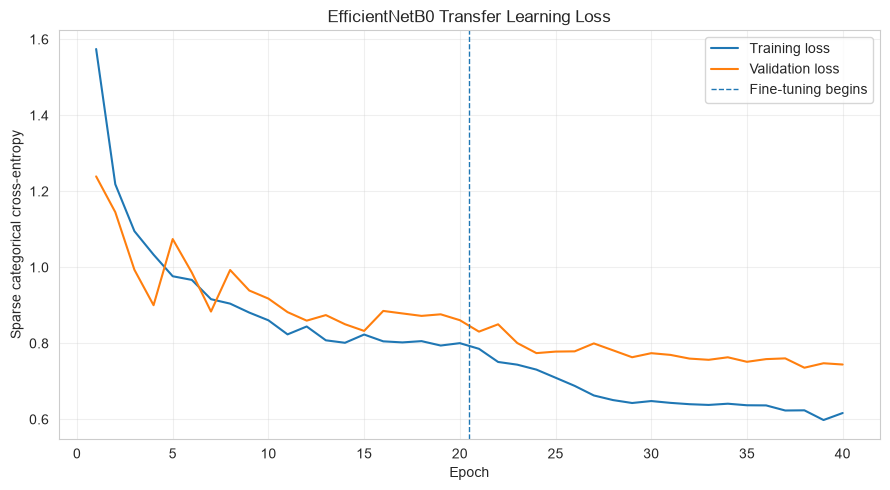

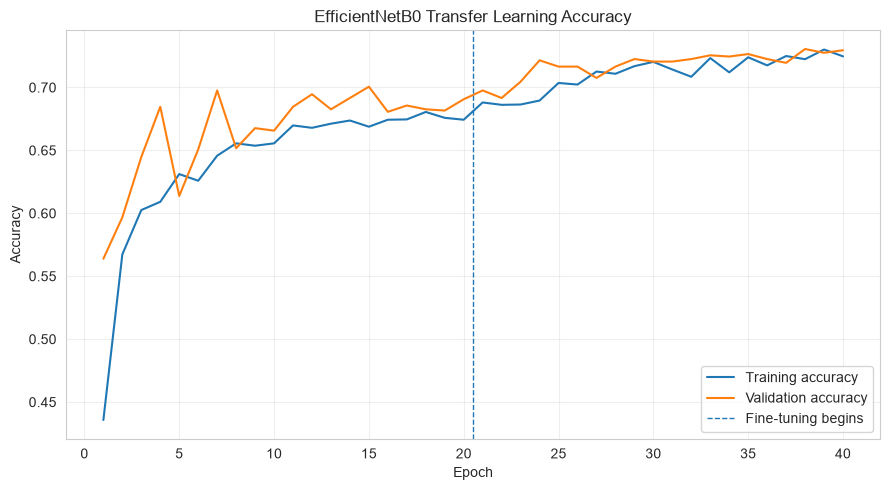

Saved: ..\outputs\figures\baseline\efficientnet_b0_baseline_training_loss.png
Saved: ..\outputs\figures\baseline\efficientnet_b0_baseline_training_accuracy.png


In [37]:
# Save EfficientNet training/fine-tuning curves to output/figures
def combine_effnet_history(metric):
    stage1 = effnet_history_stage1.history[metric]
    stage2 = effnet_history_stage2.history[metric]
    return list(stage1) + list(stage2), len(stage1)


effnet_loss, fine_tune_start = combine_effnet_history("loss")
effnet_val_loss, _ = combine_effnet_history("val_loss")
effnet_acc, _ = combine_effnet_history("accuracy")
effnet_val_acc, _ = combine_effnet_history("val_accuracy")
effnet_epochs = np.arange(1, len(effnet_loss) + 1)

plt.figure(figsize=(9, 5))
plt.plot(effnet_epochs, effnet_loss, label="Training loss")
plt.plot(effnet_epochs, effnet_val_loss, label="Validation loss")
plt.axvline(
    fine_tune_start + 0.5,
    linestyle="--",
    linewidth=1,
    label="Fine-tuning begins",
)
plt.xlabel("Epoch")
plt.ylabel("Sparse categorical cross-entropy")
plt.title("EfficientNetB0 Transfer Learning Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
effnet_loss_path = ABLATION_FIGURE_DIR / f"efficientnet_b0_{EXPERIMENT_NAME}_training_loss.png"
plt.savefig(effnet_loss_path, dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(effnet_epochs, effnet_acc, label="Training accuracy")
plt.plot(effnet_epochs, effnet_val_acc, label="Validation accuracy")
plt.axvline(
    fine_tune_start + 0.5,
    linestyle="--",
    linewidth=1,
    label="Fine-tuning begins",
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EfficientNetB0 Transfer Learning Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
effnet_accuracy_path = ABLATION_FIGURE_DIR / f"efficientnet_b0_{EXPERIMENT_NAME}_training_accuracy.png"
plt.savefig(effnet_accuracy_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", effnet_loss_path)
print("Saved:", effnet_accuracy_path)

## Models Evaluation and Comparison Figures

In [38]:
# Collect test probabilities and calculate metrics
@torch.no_grad()
def predict_torch_probabilities(model, loader, device):
    model.eval()
    batches = []
    
    for images, _ in loader:
        logits = model(images.to(device))
        batches.append(torch.softmax(logits, dim=1).cpu().numpy())
    return np.concatenate(batches, axis=0)

def evaluate_predictions(model, y_true, probabilities):
    probabilities = np.asanyarray(probabilities)
    predictions = probabilities.argmax(axis=1)
    
    metrics = {
        "Model": model,
        "Accuracy": accuracy_score(y_true, predictions),
        "Balanced Accuracy": balanced_accuracy_score(y_true, predictions),
        "Macro Precision": precision_score(y_true, predictions, labels=ALL_LABELS, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_true, predictions, labels=ALL_LABELS, average="macro", zero_division=0),
        "Macro F1": f1_score(y_true, predictions, labels=ALL_LABELS, average="macro", zero_division=0),
        "Log Loss": log_loss(y_true, probabilities, labels=ALL_LABELS),
    }
    
    return metrics, predictions

# Generate probabilities for each model on the test set
model_probs = {
    "Majority Baseline": majority_baseline.predict_proba(X_test_flat),
    "Random Forest": rf_model.predict_proba(X_test_flat),
    "LSTM": lstm_model.predict(X_test_lstm, batch_size=256),
    "Logistic Regression": logistic_model.predict_proba(X_test_flat),
    "CNN": predict_torch_probabilities(model, test_loader, device),
    "EFFicientNetB0": effnet_model.predict(effnet_test_ds, verbose=1),
}

# Compute metrics for each model
evaluation_results = []
model_predictions = {}

for model_name, probs in model_probs.items():
    metrics, predictions = evaluate_predictions(model_name, y_test, probs)
    evaluation_results.append(metrics)
    model_predictions[model_name] = predictions
    
all_results_df = (
    pd.DataFrame(evaluation_results)
    .sort_values("Macro F1", ascending=False)
    .reset_index(drop=True)
)

display(all_results_df.round(4))

print("\nLaTeX table:")
print(
    all_results_df.round(4).to_latex(
        index=False,
        float_format="%.4f",
    )
)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 200ms/step


,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Log Loss
0,EFFicientNetB0,0.7146,0.6712,0.4968,0.6712,0.5536,0.8107
1,CNN,0.6397,0.6775,0.4453,0.6775,0.5088,0.9419
2,Random Forest,0.6597,0.4051,0.3914,0.4051,0.3871,0.9001
3,LSTM,0.5150,0.5265,0.3487,0.5265,0.3722,1.1268
4,Logistic Regression,0.5569,0.4805,0.3285,0.4805,0.3535,1.3619
5,Majority Baseline,0.6697,0.1429,0.0957,0.1429,0.1146,11.9066



LaTeX table:
\begin{tabular}{lrrrrrr}
\toprule
Model & Accuracy & Balanced Accuracy & Macro Precision & Macro Recall & Macro F1 & Log Loss \\
\midrule
EFFicientNetB0 & 0.7146 & 0.6712 & 0.4968 & 0.6712 & 0.5536 & 0.8107 \\
CNN & 0.6397 & 0.6775 & 0.4453 & 0.6775 & 0.5088 & 0.9419 \\
Random Forest & 0.6597 & 0.4051 & 0.3914 & 0.4051 & 0.3871 & 0.9001 \\
LSTM & 0.5150 & 0.5265 & 0.3487 & 0.5265 & 0.3722 & 1.1268 \\
Logistic Regression & 0.5569 & 0.4805 & 0.3285 & 0.4805 & 0.3535 & 1.3619 \\
Majority Baseline & 0.6697 & 0.1429 & 0.0957 & 0.1429 & 0.1146 & 11.9066 \\
\bottomrule
\end{tabular}



## Ablation Results Save

In [39]:
# Save metrics together with the active ablation settings.
ablation_result_df = all_results_df.copy()

ablation_result_df.insert(0, "Experiment", ACTIVE_EXPERIMENT)
ablation_result_df.insert(1, "Experiment Name", EXPERIMENT_NAME)
ablation_result_df.insert(2, "Black-hat + CLAHE", USE_ENHANCEMENT)
ablation_result_df.insert(3, "Online Augmentation", USE_AUGMENTATION)

ablation_csv_path = (
    ABLATION_FIGURE_DIR /
    f"ablation_metrics_{ACTIVE_EXPERIMENT}_{EXPERIMENT_NAME}.csv"
)
ablation_result_df.to_csv(ablation_csv_path, index=False)

display(ablation_result_df.round(4))
print("Saved ablation metrics:", ablation_csv_path)

,Experiment,Experiment Name,Black-hat + CLAHE,Online Augmentation,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Log Loss
0,A,baseline,False,False,EFFicientNetB0,0.7146,0.6712,0.4968,0.6712,0.5536,0.8107
1,A,baseline,False,False,CNN,0.6397,0.6775,0.4453,0.6775,0.5088,0.9419
2,A,baseline,False,False,Random Forest,0.6597,0.4051,0.3914,0.4051,0.3871,0.9001
3,A,baseline,False,False,LSTM,0.5150,0.5265,0.3487,0.5265,0.3722,1.1268
4,A,baseline,False,False,Logistic Regression,0.5569,0.4805,0.3285,0.4805,0.3535,1.3619
5,A,baseline,False,False,Majority Baseline,0.6697,0.1429,0.0957,0.1429,0.1146,11.9066


Saved ablation metrics: ..\outputs\figures\baseline\ablation_metrics_A_baseline.csv


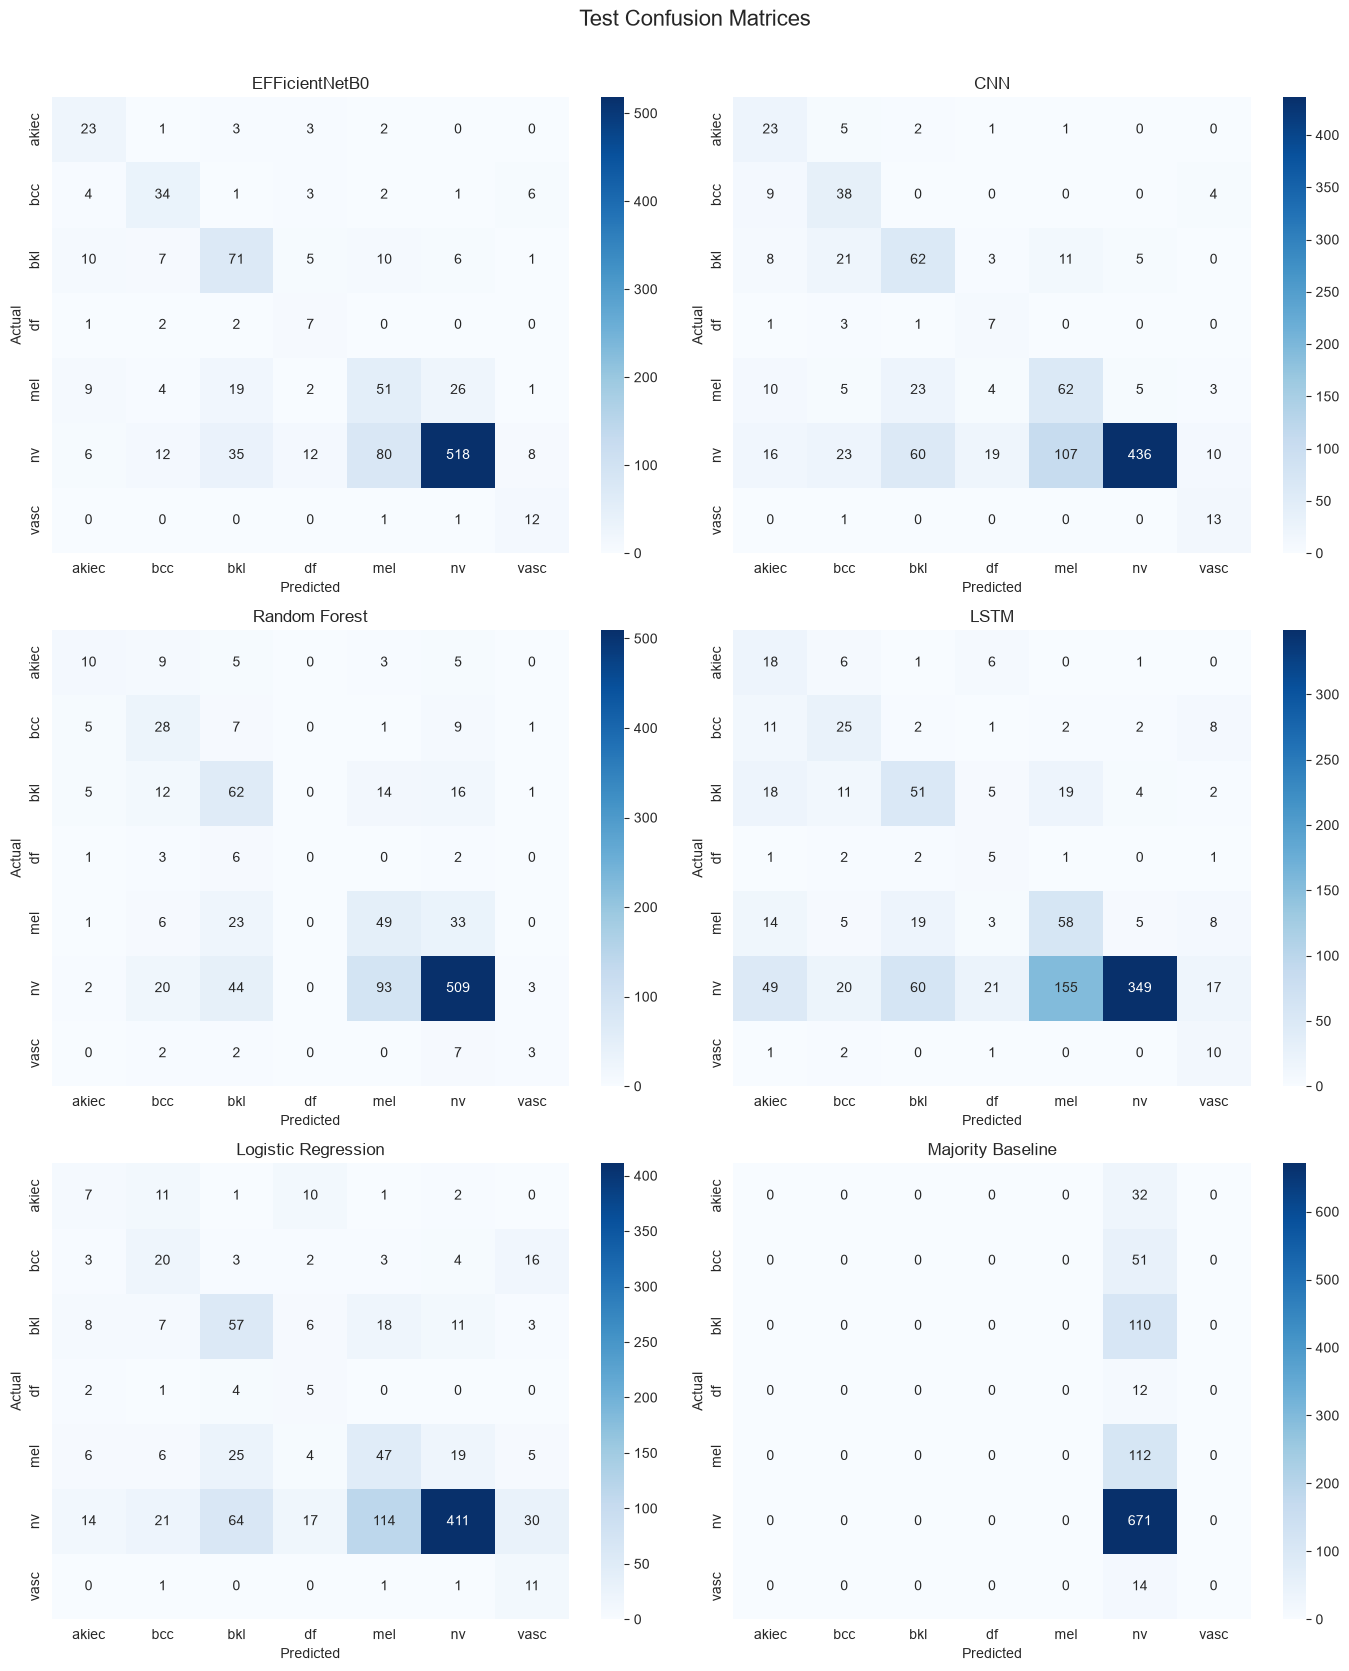

In [40]:
# Confusion matrices for every model.
n_models = len(all_results_df)
n_cols = 2
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 5.5 * n_rows),
)
axes = np.atleast_1d(axes).ravel()

for ax, model_name in zip(axes, all_results_df["Model"]):
    cm = confusion_matrix(
        y_test,
        model_predictions[model_name],
        labels=ALL_LABELS,
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax,
    )
    ax.set_title(model_name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

for ax in axes[n_models:]:
    ax.axis("off")

fig.suptitle("Test Confusion Matrices", fontsize=16, y=1.01)
plt.tight_layout()
cfs_matrix_path = ABLATION_FIGURE_DIR / f"confusion_matrix_{EXPERIMENT_NAME}.png"
plt.savefig(cfs_matrix_path, dpi=300, bbox_inches="tight")
plt.show()

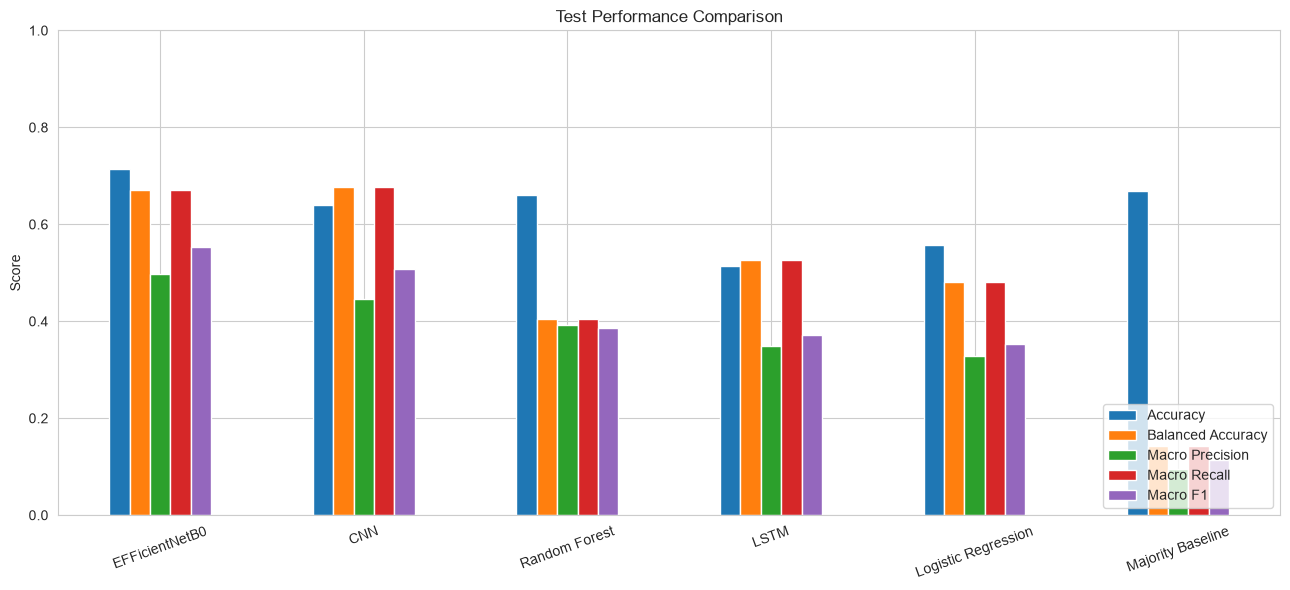

In [41]:
# Side-by-side comparison of the main threshold-based metrics.
comparison_metrics = [
    "Accuracy",
    "Balanced Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
]

(
    all_results_df
    .set_index("Model")[comparison_metrics]
    .plot(
        kind="bar",
        figsize=(13, 6),
        ylim=(0, 1),
        rot=20,
    )
)

plt.title("Test Performance Comparison")
plt.ylabel("Score")
plt.xlabel("")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

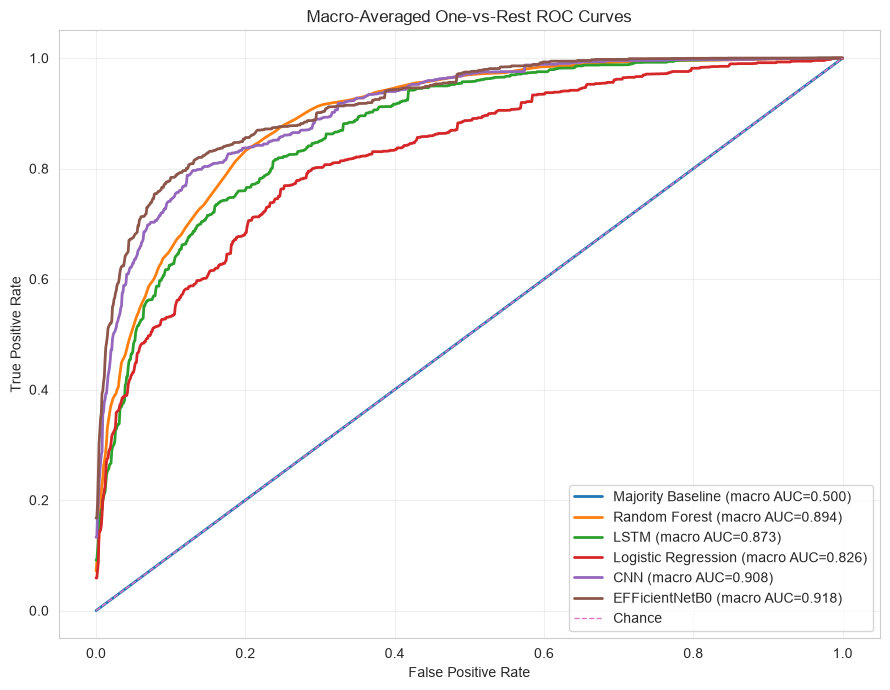

In [42]:
# Multiclass one-vs-rest ROC curves using macro-average AUC.
# The majority-class baseline is excluded because its probability matrix is
# degenerate and is not informative as an ROC comparator.
y_test_binary = label_binarize(y_test, classes=ALL_LABELS)

roc_models = {
    name: probabilities
    for name, probabilities in model_probs.items()
    if name != "Majority Class Baseline"
}

plt.figure(figsize=(9, 7))

for model_name, probabilities in roc_models.items():
    fpr_grid = np.linspace(0, 1, 1000)
    interpolated_tprs = []
    valid_class_aucs = []

    for class_id in ALL_LABELS:
        targets = y_test_binary[:, class_id]

        # A one-vs-rest ROC is undefined if this test fold has only one class.
        if np.unique(targets).size < 2:
            continue

        fpr, tpr, _ = roc_curve(
            targets,
            probabilities[:, class_id],
        )
        interpolated_tprs.append(
            np.interp(fpr_grid, fpr, tpr)
        )
        valid_class_aucs.append(auc(fpr, tpr))

    if not valid_class_aucs:
        continue

    macro_tpr = np.mean(interpolated_tprs, axis=0)
    macro_auc = float(np.mean(valid_class_aucs))

    plt.plot(
        fpr_grid,
        macro_tpr,
        linewidth=2,
        label=f"{model_name} (macro AUC={macro_auc:.3f})",
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    label="Chance",
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Macro-Averaged One-vs-Rest ROC Curves")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
roc_path = ABLATION_FIGURE_DIR / f"roc_curves_{EXPERIMENT_NAME}.png"
plt.savefig(roc_path, dpi=300, bbox_inches="tight")
plt.show()

## Training Diagnostics

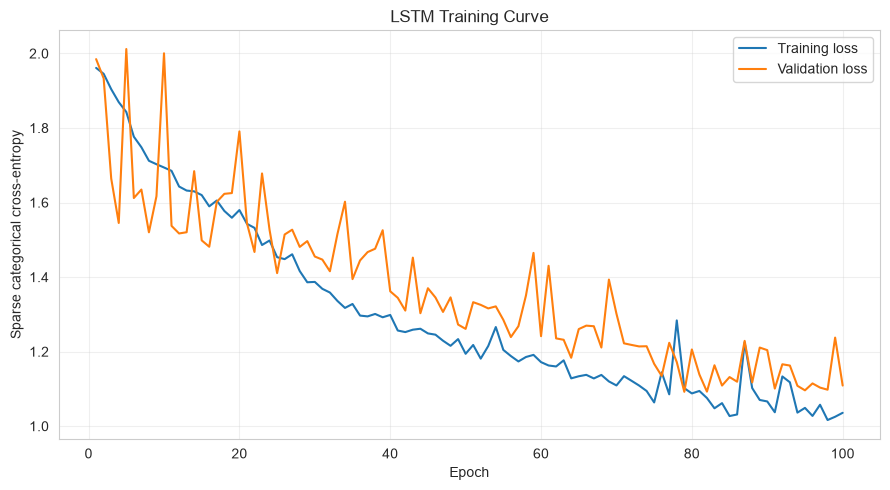

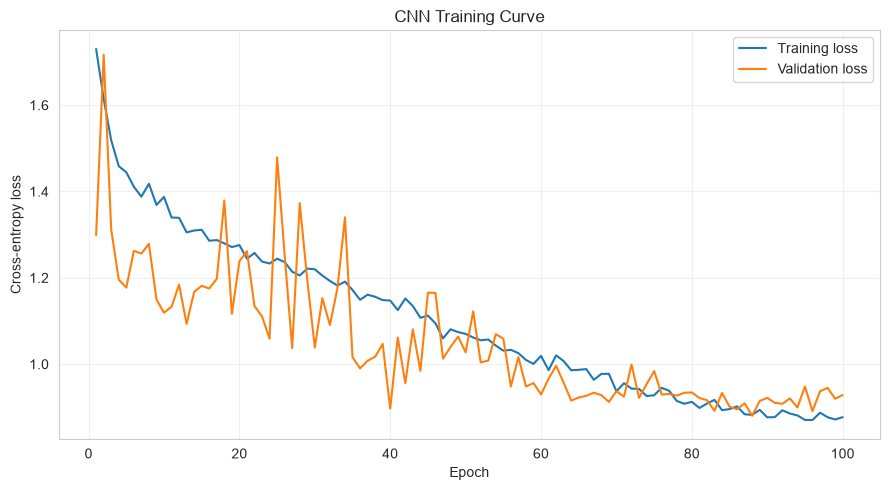

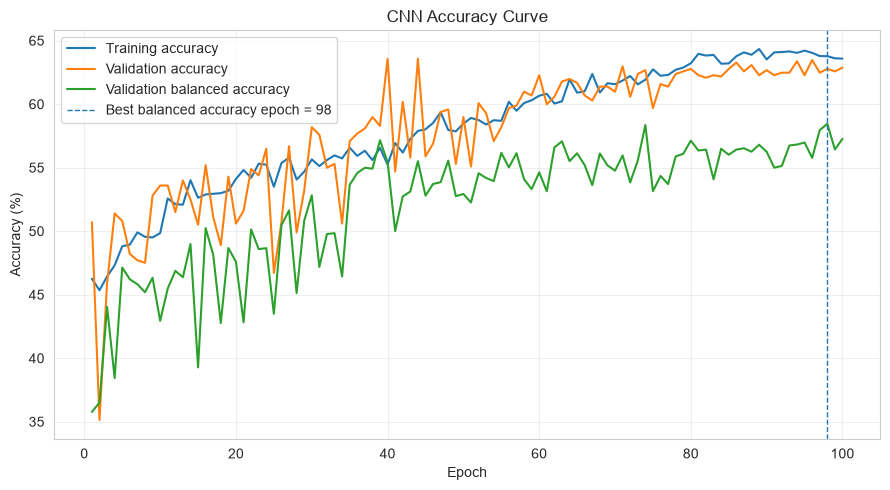

In [43]:
# Training curves are grouped here as diagnostics rather than mixed into
# the individual model-training cells.

# LSTM loss
epochs_lstm = range(1, len(lstm_history.history["loss"]) + 1)
plt.figure(figsize=(9, 5))
plt.plot(epochs_lstm, lstm_history.history["loss"], label="Training loss")
plt.plot(epochs_lstm, lstm_history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Sparse categorical cross-entropy")
plt.title("LSTM Training Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
LSTM_training_curve_path = ABLATION_FIGURE_DIR / "lstm_training_curve.png"
plt.savefig(LSTM_training_curve_path, dpi=300, bbox_inches="tight")
plt.show()

# CNN loss
epochs_cnn = range(1, len(cnn_history["train_loss"]) + 1)
plt.figure(figsize=(9, 5))
plt.plot(epochs_cnn, cnn_history["train_loss"], label="Training loss")
plt.plot(epochs_cnn, cnn_history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("CNN Training Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
CNN_training_curve_path = ABLATION_FIGURE_DIR / "cnn_training_curve.png"
plt.savefig(CNN_training_curve_path, dpi=300, bbox_inches="tight")
plt.show()

# CNN accuracy
best_epoch = (
    np.argmax(cnn_history["val_bal_acc"]) + 1
)

best_bal_acc = max(
    cnn_history["val_bal_acc"]
)

plt.figure(figsize=(9, 5))
plt.plot(epochs_cnn, cnn_history["train_acc"], label="Training accuracy")
plt.plot(epochs_cnn, cnn_history["val_acc"], label="Validation accuracy")
plt.plot(epochs_cnn,cnn_history["val_bal_acc"], label="Validation balanced accuracy")

plt.axvline(
    best_epoch,
    linestyle="--",
    linewidth=1,
    label=f"Best balanced accuracy epoch = {best_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("CNN Accuracy Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
cnn_acc_curve_path = ABLATION_FIGURE_DIR / "cnn_accuracy_curve.png"
plt.savefig(cnn_acc_curve_path, dpi=300, bbox_inches="tight")
plt.show()